In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [29]:
df = pd.read_csv('Data_Polis.csv')
df2 = pd.read_csv('Data_Klaim.csv')

In [30]:
df['Nomor Polis'] = df['Nomor Polis'].str.strip()
df2['Nomor Polis'] = df2['Nomor Polis'].str.strip()

df_final = pd.merge(df, df2, on='Nomor Polis', how='left')

print(f"Jumlah baris df_polis: {len(df)}")
print(f"Jumlah baris df_klaim: {len(df2)}")
print(f"Jumlah baris hasil merge: {len(df_final)}")

display(df_final.head())

Jumlah baris df_polis: 4096
Jumlah baris df_klaim: 4627
Jumlah baris hasil merge: 7513


,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili,Claim ID,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,POL-0001,M-003,M,19640811,20140603,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,POL-0002,M-003,M,19710730,20140603,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,POL-0003,M-001,M,19790821,20160808,JAKARTA,C-3535-M,C,IP,S83.2,"TEAR OF MENISCUS, CURRENT",PAID,2024-10-31,2024-09-09,2024-09-10,14138163.0,14138163.0,Indonesia
3,POL-0004,M-003,M,20140724,20160811,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,POL-0005,M-001,F,19810114,20150828,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
df_final['Nominal Klaim Yang Disetujui'] = df_final['Nominal Klaim Yang Disetujui'].fillna(0)

In [32]:
# metodology explicit 
display(df_final.head())

,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili,Claim ID,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,POL-0001,M-003,M,19640811,20140603,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
1,POL-0002,M-003,M,19710730,20140603,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
2,POL-0003,M-001,M,19790821,20160808,JAKARTA,C-3535-M,C,IP,S83.2,"TEAR OF MENISCUS, CURRENT",PAID,2024-10-31,2024-09-09,2024-09-10,14138163.0,14138163.0,Indonesia
3,POL-0004,M-003,M,20140724,20160811,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
4,POL-0005,M-001,F,19810114,20150828,JAKARTA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN


In [33]:
cols_to_zero = ['Nominal Klaim Yang Disetujui', 'Nominal Biaya RS Yang Terjadi']
df_final[cols_to_zero] = df_final[cols_to_zero].fillna(0)

df_final['is_claim'] = df_final['Claim ID'].notnull().astype(int)

cat_cols = [
    'Claim ID', 'Reimburse/Cashless', 'Inpatient/Outpatient', 
    'ICD Diagnosis', 'ICD Description', 'Lokasi RS', 'Status Klaim'
]

for col in cat_cols:
    df_final.loc[df_final['is_claim'] == 0, col] = 'No Claim'
    df_final[col] = df_final[col].fillna('Unknown')


In [34]:
display(df_final.head())

,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili,Claim ID,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS,is_claim
0,POL-0001,M-003,M,19640811,20140603,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaN,NaN,NaN,0.0,0.0,No Claim,0
1,POL-0002,M-003,M,19710730,20140603,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaN,NaN,NaN,0.0,0.0,No Claim,0
2,POL-0003,M-001,M,19790821,20160808,JAKARTA,C-3535-M,C,IP,S83.2,"TEAR OF MENISCUS, CURRENT",PAID,2024-10-31,2024-09-09,2024-09-10,14138163.0,14138163.0,Indonesia,1
3,POL-0004,M-003,M,20140724,20160811,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaN,NaN,NaN,0.0,0.0,No Claim,0
4,POL-0005,M-001,F,19810114,20150828,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaN,NaN,NaN,0.0,0.0,No Claim,0


In [35]:
df_final['Tanggal Lahir'] = pd.to_datetime(df_final['Tanggal Lahir'], format='%Y%m%d', errors='coerce')
df_final['Tanggal Efektif Polis'] = pd.to_datetime(df_final['Tanggal Efektif Polis'], format='%Y%m%d', errors='coerce')

df_final['Tanggal Pasien Masuk RS'] = pd.to_datetime(df_final['Tanggal Pasien Masuk RS'], errors='coerce')
df_final['Tanggal Pasien Keluar RS'] = pd.to_datetime(df_final['Tanggal Pasien Keluar RS'], errors='coerce')
df_final['Tanggal Pembayaran Klaim'] = pd.to_datetime(df_final['Tanggal Pembayaran Klaim'], errors='coerce')

display(df_final[df_final['is_claim'] == 1][['Nomor Polis', 'Tanggal Pasien Masuk RS']].head())

,Nomor Polis,Tanggal Pasien Masuk RS
2,POL-0003,2024-09-09
5,POL-0006,2024-08-16
6,POL-0006,2024-10-23
10,POL-0010,2024-01-19
11,POL-0010,2024-01-18


In [36]:
display(df_final.head())

,Nomor Polis,Plan Code,Gender,Tanggal Lahir,Tanggal Efektif Polis,Domisili,Claim ID,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS,is_claim
0,POL-0001,M-003,M,1964-08-11,2014-06-03,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaT,NaT,NaT,0.0,0.0,No Claim,0
1,POL-0002,M-003,M,1971-07-30,2014-06-03,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaT,NaT,NaT,0.0,0.0,No Claim,0
2,POL-0003,M-001,M,1979-08-21,2016-08-08,JAKARTA,C-3535-M,C,IP,S83.2,"TEAR OF MENISCUS, CURRENT",PAID,2024-10-31,2024-09-09,2024-09-10,14138163.0,14138163.0,Indonesia,1
3,POL-0004,M-003,M,2014-07-24,2016-08-11,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaT,NaT,NaT,0.0,0.0,No Claim,0
4,POL-0005,M-001,F,1981-01-14,2015-08-28,JAKARTA,No Claim,No Claim,No Claim,No Claim,No Claim,No Claim,NaT,NaT,NaT,0.0,0.0,No Claim,0



Missing value
Tanggal Pembayaran Klaim    2923
Tanggal Pasien Masuk RS     2886
Tanggal Pasien Keluar RS    2886
dtype: int64


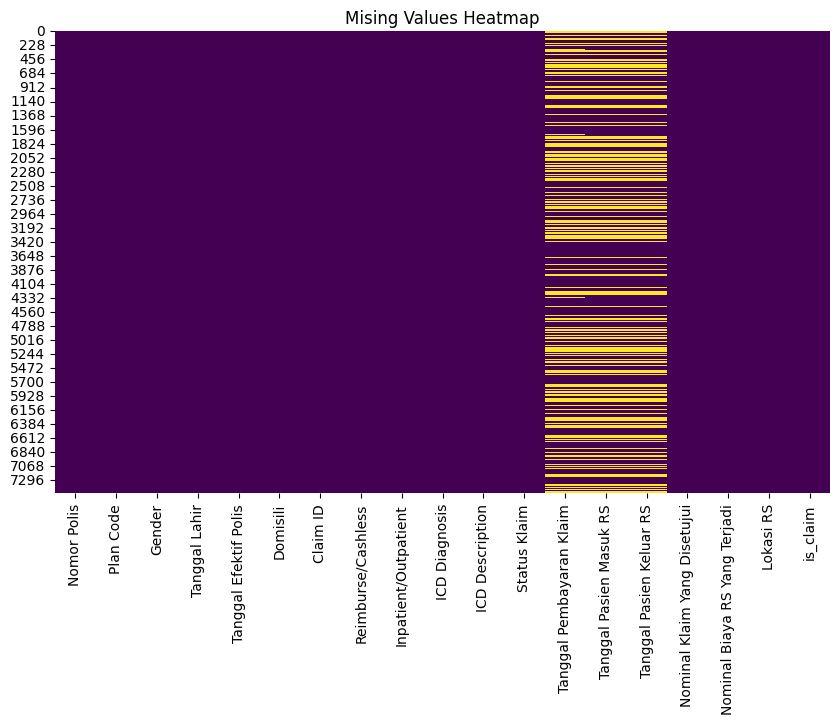

In [37]:
# missing value check
print("\nMissing value")
missing_values = df_final.isnull().sum()
print(missing_values[missing_values > 0]) 

plt.figure(figsize=(10, 6))
sns.heatmap(df_final.isnull(), cbar=False, cmap='viridis')
plt.title('Mising Values Heatmap')
plt.show()

In [ ]:
df = pd.read_csv('Data_Polis.csv')
df2 = pd.read_csv('Data_Klaim.csv')